# DAY 01

In [22]:
import torch
from torchvision import datasets

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

In [23]:
print(len(train_data))

60000


In [24]:
image, label = train_data[0]

print(image)
print(label)

<PIL.Image.Image image mode=L size=28x28 at 0x7CB2D54A47D0>
5


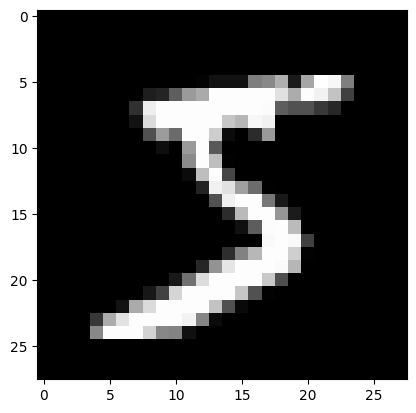

In [25]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.show()

In [26]:
print(len(train_data))
print(train_data[0])

60000
(<PIL.Image.Image image mode=L size=28x28 at 0x7CB2D52E3C50>, 5)


In [27]:
import torch
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

In [28]:
image, label = train_data[0]

print(image)
print(label)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [29]:
print(image.shape)

torch.Size([1, 28, 28])


[채널 수, 높이, 넓이]

In [30]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

In [31]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


완전 연결 신경망

In [32]:
import torch.nn as nn

In [33]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(28 * 28, 10) # 0-9까지 판단

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.fc(x)
        return x

In [34]:
model = SimpleNN()

images, labels = next(iter(train_loader))

outputs = model(images)

print(outputs.shape)

torch.Size([64, 10])


In [35]:
loss_fn = nn.CrossEntropyLoss()

loss = loss_fn(outputs, labels)

print(loss)

tensor(2.2929, grad_fn=<NllLossBackward0>)


In [36]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=0.01)

optimizer.zero_grad()

loss.backward()

optimizer.step()

In [37]:
for i in range(10):
    optimizer.zero_grad()

    outputs = model(images)
    loss = loss_fn(outputs, labels)

    loss.backward()
    optimizer.step()

    print(i + 1, loss.item())

1 2.276254415512085
2 2.259883403778076
3 2.2437658309936523
4 2.2278904914855957
5 2.2122485637664795
6 2.1968297958374023
7 2.181626081466675
8 2.1666293144226074
9 2.151832342147827
10 2.1372275352478027


In [38]:
predictions = torch.argmax(outputs, dim=1)

print("예측:", predictions[:10])
print("정답:", labels[:10])

예측: tensor([0, 8, 3, 6, 0, 7, 6, 9, 7, 0])
정답: tensor([9, 1, 3, 9, 0, 7, 6, 2, 7, 2])


In [39]:
for epoch in range(3):
    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.4836
Epoch 2, Loss: 0.4735
Epoch 3, Loss: 0.3123


In [40]:
test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [41]:
correct = 0
total = 0

for images, labels in test_loader:
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

    correct += (predictions == labels).sum().item()
    total += labels.size(0)

accuracy = correct / total

print(f"정확도: {accuracy * 100:.2f}%")

정확도: 89.13%


In [42]:
class BetterNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

In [43]:
model = BetterNN()

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [44]:
for epoch in range(3):
    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0569
Epoch 2, Loss: 0.1927
Epoch 3, Loss: 0.1203


In [45]:
correct = 0
total = 0

for images, labels in test_loader:
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

    correct += (predictions == labels).sum().item()
    total += labels.size(0)

accuracy = correct / total

print(f"정확도: {accuracy * 100:.2f}%")

정확도: 96.67%


# DAY 02

In [2]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn as nn

train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

image, label = train_data[0]

conv = nn.Conv2d(
    in_channels=1,
    out_channels=8,
    kernel_size=3
)

output = conv(image.unsqueeze(0))

print(output.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 613kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]

torch.Size([1, 8, 26, 26])


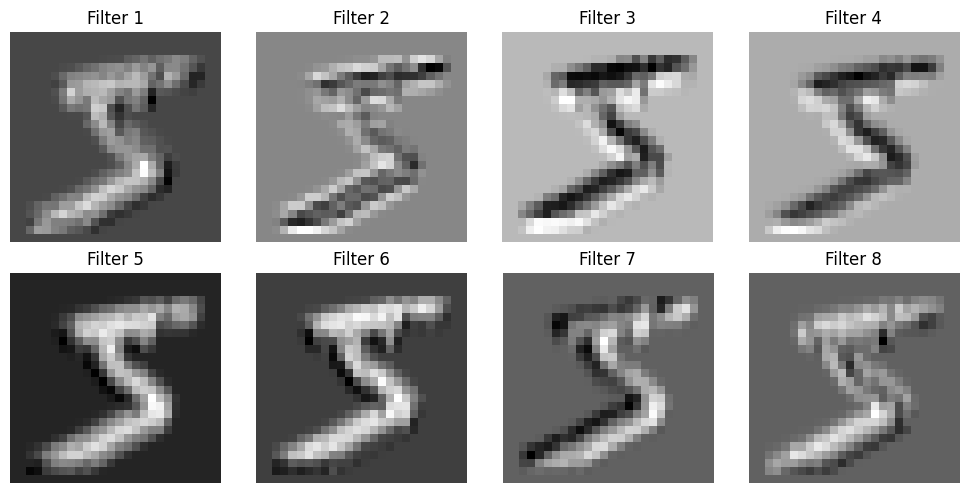

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(output[0, i].detach().numpy(), cmap="gray")
    ax.set_title(f"Filter {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2
        )

        self.fc = nn.Linear(
            8 * 13 * 13,
            10
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.flatten(1)

        x = self.fc(x)

        return x

In [5]:
model = SimpleCNN()

print(model)

SimpleCNN(
  (conv): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=1352, out_features=10, bias=True)
)


In [6]:
image, label = train_data[0]

x = image.unsqueeze(0)

output = model(x)

print(output.shape)
print(output)

torch.Size([1, 10])
tensor([[-0.0275,  0.0267,  0.1801,  0.0520,  0.0902,  0.2124,  0.0998,  0.0374,
         -0.0876,  0.0547]], grad_fn=<AddmmBackward0>)


In [7]:
loss_fn = nn.CrossEntropyLoss()

loss = loss_fn(output, torch.tensor([label]))

print(loss)

tensor(2.1576, grad_fn=<NllLossBackward0>)


In [8]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

In [9]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

In [10]:
output2 = model(x)
loss2 = loss_fn(output2, torch.tensor([label]))

print(output2)
print(loss2)

tensor([[-0.0871, -0.0342,  0.1108, -0.0107,  0.0252,  0.7729,  0.0337, -0.0255,
         -0.1435, -0.0068]], grad_fn=<AddmmBackward0>)
tensor(1.6295, grad_fn=<NllLossBackward0>)


In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

print(len(train_loader))

938


In [12]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [13]:
images, labels = next(iter(train_loader))

output = model(images)

print(images.shape)
print(labels.shape)
print(output.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])
torch.Size([64, 10])


In [14]:
loss = loss_fn(output, labels)

print(loss)

tensor(2.3373, grad_fn=<NllLossBackward0>)


In [15]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

In [18]:
output2 = model(images)
loss2 = loss_fn(output2, labels)

print(loss2)

tensor(0.3142, grad_fn=<NllLossBackward0>)


In [17]:
for images, labels in train_loader:
    output = model(images)
    loss = loss_fn(output, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [19]:
pred = output2.argmax(dim=1)

print(pred)
print(labels)

tensor([5, 9, 6, 9, 0, 4, 1, 6, 4, 5, 9, 1, 3, 1, 7, 3, 2, 1, 1, 0, 7, 2, 1, 4,
        7, 9, 5, 5, 7, 4, 5, 5])
tensor([8, 9, 6, 9, 0, 4, 1, 6, 4, 5, 4, 1, 3, 1, 2, 3, 2, 1, 1, 7, 7, 2, 1, 4,
        7, 9, 5, 5, 7, 4, 5, 5])


In [20]:
correct = (pred == labels).sum()

print(correct)
print(correct / len(labels))

tensor(28)
tensor(0.8750)


In [47]:
test_data = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

In [48]:
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [49]:
test_images, test_labels = next(iter(test_loader))

print(test_images.shape)
print(test_labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [50]:
test_output = model(test_images)

test_pred = test_output.argmax(dim=1)

print(test_pred)
print(test_labels)

tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3])


In [51]:
correct = (test_pred == test_labels).sum()

print(correct)
print(correct / len(test_labels))

tensor(63)
tensor(0.9844)


In [52]:
correct = 0
total = 0

for test_images, test_labels in test_loader:
    test_output = model(test_images)
    test_pred = test_output.argmax(dim=1)

    correct += (test_pred == test_labels).sum().item()
    total += test_labels.size(0)

accuracy = correct / total

print("맞힌 개수:", correct)
print("전체 개수:", total)
print("정확도:", accuracy)

맞힌 개수: 9667
전체 개수: 10000
정확도: 0.9667


In [53]:
num_epochs = 5

for epoch in range(num_epochs):
    # 학습
    model.train()

    for images, labels in train_loader:
        output = model(images)
        loss = loss_fn(output, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # 테스트
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_output = model(test_images)
            test_pred = test_output.argmax(dim=1)

            correct += (test_pred == test_labels).sum().item()
            total += test_labels.size(0)

    accuracy = correct / total

    print(
        f"Epoch {epoch + 1}/{num_epochs} "
        f"- Loss: {loss.item():.4f} "
        f"- Test Accuracy: {accuracy:.4f}"
    )

Epoch 1/5 - Loss: 0.1281 - Test Accuracy: 0.9706
Epoch 2/5 - Loss: 0.0139 - Test Accuracy: 0.9744
Epoch 3/5 - Loss: 0.0039 - Test Accuracy: 0.9748
Epoch 4/5 - Loss: 0.0117 - Test Accuracy: 0.9759
Epoch 5/5 - Loss: 0.0533 - Test Accuracy: 0.9786


In [54]:
model.eval()

wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        output = model(images)
        preds = output.argmax(dim=1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                wrong_images.append(images[i])
                wrong_preds.append(preds[i].item())
                wrong_labels.append(labels[i].item())

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


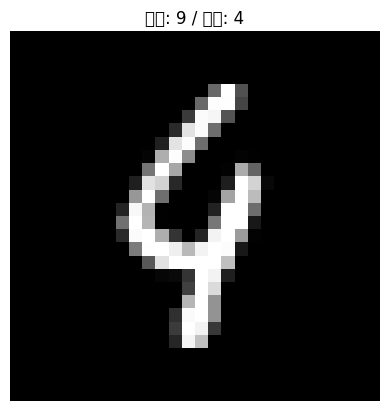

In [55]:
import matplotlib.pyplot as plt

plt.imshow(wrong_images[0].squeeze(), cmap="gray")
plt.title(
    f"예측: {wrong_preds[0]} / 실제: {wrong_labels[0]}"
)
plt.axis("off")
plt.show()

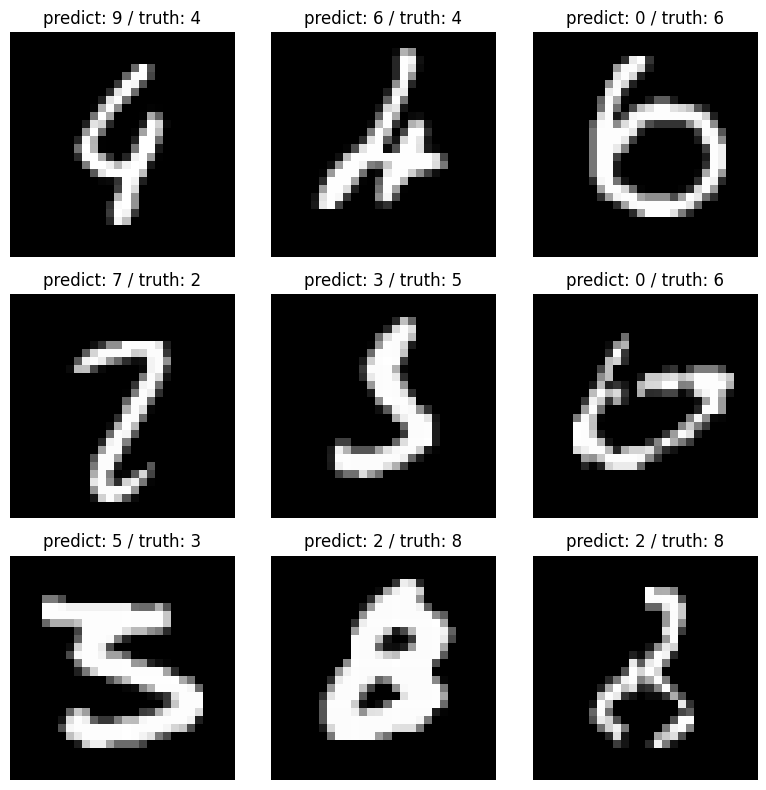

In [56]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(wrong_images[i].squeeze(), cmap="gray")
    ax.set_title(
        f"predict: {wrong_preds[i]} / truth: {wrong_labels[i]}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1023/1409982453.py:13: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1409982453.py:13: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1409982453.py:13: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1023/1409982453.py:13: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


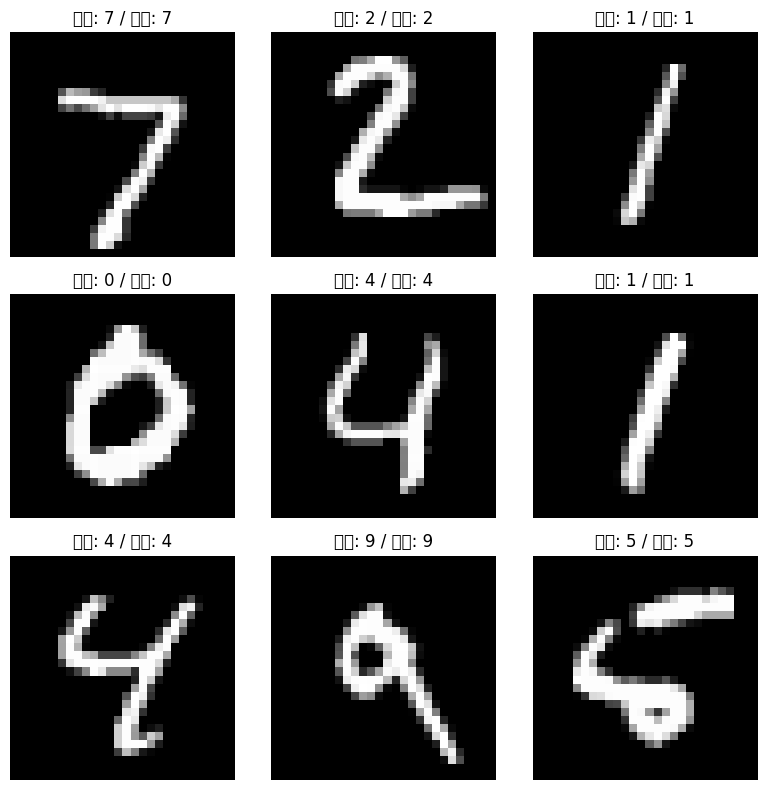

In [57]:
images, labels = next(iter(test_loader))

output = model(images)
preds = output.argmax(dim=1)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f"예측: {preds[i].item()} / 실제: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()